# Alertas de contaminación a 24 horas — Beijing

Notebook independiente del modelo global `05_2`. Compara **regresión base, peso 3 en horas altas y cuantil 0,8**, todos entrenados con `skforecast.ForecasterRecursive`, y persistencia.

Objetivo: anticipar horas con **PM2.5 > 150 µg/m³**. Se conserva la definición del proyecto; no se interpreta como norma sanitaria. El umbral real 150 y el umbral para emitir un aviso son distintos.

**Protocolo:** enero–agosto de 2013 para ajustar umbrales con predicciones temporales fuera de entrenamiento; septiembre–diciembre para elegir la política; reentrenamiento hasta 2013 y evaluación reutilizada de 2014. Se selecciona por recall con precisión mínima configurable, no por RMSE. Si no hay política factible, se informa y se elige F2 como referencia exploratoria.

La primera ejecución usa precisión mínima del 50 %, una hipótesis de trabajo, no un requisito operativo acordado. Los resultados previos ya han usado 2013 y 2014: esto no es un test totalmente nuevo. Se evalúan episodios con inicio observado y se distingue aviso anticipado de acierto durante un episodio ya iniciado.

In [1]:
from pathlib import Path
from time import perf_counter
import importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (precision_score, recall_score, fbeta_score,
                            mean_squared_error, mean_absolute_error,
                            average_precision_score, precision_recall_curve)
from skforecast.recursive import ForecasterRecursive
from threadpoolctl import threadpool_limits

INICIO = perf_counter()
H, UMBRAL, SEMILLA = 24, 150, 42
PRECISION_MINIMA = 0.50
REJILLA_UMBRALES = np.arange(50, 201, 5)
LAGS = [24, 25, 26, 27, 30, 36, 48]
RAIZ = next((p.resolve() for p in [Path('.'), Path('..')]
             if (p / 'data/processed/beijing_data_huecos_24h.csv').exists()), None)
if RAIZ is None:
    raise FileNotFoundError('Abrir este notebook desde beijing-air-quality/notebooks o desde la raíz del proyecto')
VERSIONES = {p: metadata.version(p) for p in ['skforecast', 'scikit-learn', 'pandas', 'numpy']}
print('Versiones:', VERSIONES)
print('Raíz:', RAIZ)

Versiones: {'skforecast': '0.25.0', 'scikit-learn': '1.9.1', 'pandas': '2.3.3', 'numpy': '2.5.3'}
Raíz: C:\Users\martin\Documents\uc3m - Applied AI\uc3m - Series Temporales\beijing-air-quality


c:\Users\martin\Documents\uc3m - Applied AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="The 'generic' unit for NumPy timedelta is deprecated.*",
    category=DeprecationWarning
)

## 1. Datos

Se usa `data/processed/beijing_data_huecos_24h.csv` como matriz principal y
`data/processed/beijing_data_preparado.csv` únicamente para identificar imputaciones.
Los objetivos imputados no se evalúan; objetivos o lags imputados reciben peso cero.
En predicción se permite historial rellenado hacia delante, igual que en el modelo de referencia.

In [3]:
principal = RAIZ / 'data/processed/beijing_data_huecos_24h.csv'
auxiliar = RAIZ / 'data/processed/beijing_data_preparado.csv'
df = pd.read_csv(principal, index_col='datetime', parse_dates=True).sort_index()
assert df.index.is_unique
df = df.asfreq('h')
traza = pd.read_csv(auxiliar, index_col='datetime', parse_dates=True).sort_index()
marca = traza['pm2.5_imputado'].reindex(df.index)
assert marca.notna().all() and marca.isin([True, False, 0, 1]).all()
imputado = marca.astype(bool) | df['pm2.5'].isna()
real = df['pm2.5'].mask(imputado)
y = df['pm2.5'].ffill()
exog = df.drop(columns='pm2.5')
assert y.notna().all(), 'Hay huecos iniciales: recortar antes de entrenar'
assert np.isfinite(exog.to_numpy()).all(), 'Exógenas incompletas'
afectado = imputado.copy()
for lag in LAGS:
    afectado |= imputado.shift(lag, fill_value=True)
print(f'Horas: {len(df)} | Exógenas: {exog.shape[1]} | Objetivos excluidos: {imputado.sum()}')
display(exog.head())

Horas: 43752 | Exógenas: 24 | Objetivos excluidos: 2043


,cal_sen_hora,cal_cos_hora,cal_sen_dia,cal_cos_dia,cal_sen_mes,cal_cos_mes,DEWP_obs_24,TEMP_obs_24,PRES_obs_24,Iws_obs_24,...,viento_SE_obs_24,TEMP_trend_24_30,TEMP_trend_24_36,TEMP_trend_24_48,PRES_trend_24_30,PRES_trend_24_36,PRES_trend_24_48,DEWP_trend_24_30,DEWP_trend_24_36,DEWP_trend_24_48
datetime,,,,,,,,,,,,,,,,,,,,,
2010-01-04 00:00:00,0.000000,1.000000,0.0,1.0,0.0,1.0,-7.0,-6.0,1027.0,58.56,...,1,-1.0,-1.0,-2.0,0.0,1.0,7.0,1.0,1.0,9.0
2010-01-04 01:00:00,0.258819,0.965926,0.0,1.0,0.0,1.0,-8.0,-6.0,1026.0,61.69,...,1,-1.0,-1.0,-2.0,-2.0,1.0,6.0,0.0,0.0,7.0
2010-01-04 02:00:00,0.500000,0.866025,0.0,1.0,0.0,1.0,-8.0,-7.0,1026.0,65.71,...,1,-2.0,-2.0,-2.0,-2.0,1.0,5.0,-1.0,1.0,3.0
2010-01-04 03:00:00,0.707107,0.707107,0.0,1.0,0.0,1.0,-8.0,-7.0,1025.0,68.84,...,1,-2.0,-2.0,-2.0,-2.0,0.0,3.0,-1.0,1.0,-1.0
2010-01-04 04:00:00,0.866025,0.500000,0.0,1.0,0.0,1.0,-8.0,-7.0,1024.0,72.86,...,1,-1.0,-2.0,-2.0,-4.0,-2.0,2.0,0.0,1.0,-1.0


## 2. Entrenamiento y predicción por lotes

Skforecast construye los lags y ajusta el estimador. Como todos los lags son ≥ 24,
la predicción para t solo usa PM2.5 hasta t−24. El paso 24 no depende de pasos
intermedios: se puede predecir por lotes. Esta equivalencia deja de valer con lags
menores, transformaciones o nuevas ventanas no verificadas.

El cuantil 0,8 representa un pronóstico alto, **no una probabilidad calibrada**.
La concentración media y el cuantil tienen objetivos diferentes; el RMSE de ambos
se informa, pero no se espera que el cuantil alto minimice RMSE.

In [4]:
CONFIGURACIONES = {
    'base': {'peso': 1, 'cuantil': None},
    'peso_3': {'peso': 3, 'cuantil': None},
    'cuantil_80': {'peso': 1, 'cuantil': 0.8},
}

def crear_forecaster(nombre):
    conf = CONFIGURACIONES[nombre]
    extra = {} if conf['cuantil'] is None else {'loss': 'quantile', 'quantile': conf['cuantil']}
    estimador = HistGradientBoostingRegressor(
        max_leaf_nodes=7, max_iter=200, learning_rate=0.05,
        min_samples_leaf=30, early_stopping=False, random_state=SEMILLA, **extra)
    def pesos(index):
        validos = ~afectado.reindex(index).fillna(True)
        return validos.to_numpy().astype(float) * np.where(
            real.reindex(index).to_numpy() > UMBRAL, conf['peso'], 1)
    return ForecasterRecursive(estimator=estimador, lags=LAGS, weight_func=pesos)

def ajustar(nombre, fin):
    f = crear_forecaster(nombre)
    with threadpool_limits(limits=2):
        f.fit(y=y.loc[:fin], exog=exog.loc[:fin])
    return f

def predecir(f, indice):
    assert min(f.lags) >= H
    X, _ = f.create_train_X_y(y=y, exog=exog)
    with threadpool_limits(limits=2):
        pred = f.estimator.predict(X.loc[indice].to_numpy())
    return pd.Series(pred, index=indice).clip(lower=0)

def metricas(verdad, score, umbral):
    validos = verdad.notna() & score.notna()
    yt, yp = verdad[validos], score[validos]
    assert len(yt) > 0
    alta, alerta = yt > UMBRAL, yp > umbral
    vp, fp, fn = int((alta & alerta).sum()), int((~alta & alerta).sum()), int((alta & ~alerta).sum())
    return {'n': len(yt), 'horas_altas': int(alta.sum()),
            'recall': recall_score(alta, alerta, zero_division=0),
            'precision': precision_score(alta, alerta, zero_division=0),
            'F2': fbeta_score(alta, alerta, beta=2, zero_division=0),
            'AP': average_precision_score(alta, yp) if alta.any() else np.nan,
            'falsas_alarmas_h': fp, 'omitidas_h': fn,
            'avisos_h': int(alerta.sum()), 'fraccion_h_con_aviso': float(alerta.mean()),
            'RMSE': float(np.sqrt(mean_squared_error(yt, yp))),
            'MAE': mean_absolute_error(yt, yp)}

## 3. Predicciones temporales de 2013

Nueve ajustes: tres modelos por tres rondas. Cada entrenamiento termina antes del
primer origen evaluado. Se conserva el calendario completo y se filtran objetivos
medidos al calcular métricas. La primera hora objetivo de cada ronda es 24 horas
después del primer origen, igual que en el notebook de referencia.

In [5]:
PLIEGUES = [
    ('2012-12-31 23:00', '2013-01-01', '2013-04-30 23:00'),
    ('2013-04-30 23:00', '2013-05-01', '2013-08-31 23:00'),
    ('2013-08-31 23:00', '2013-09-01', '2013-12-31 23:00'),
]
partes = []
for ronda, (fin_train, inicio, fin) in enumerate(PLIEGUES, 1):
    indice = y.loc[pd.Timestamp(inicio) + pd.Timedelta(hours=H):fin].index
    assert pd.Timestamp(fin_train) < indice.min() - pd.Timedelta(hours=H)
    parte = pd.DataFrame({'real': real.loc[indice], 'persistencia': y.shift(H).loc[indice], 'ronda': ronda})
    for nombre in CONFIGURACIONES:
        inicio_ajuste = perf_counter()
        f = ajustar(nombre, fin_train)
        parte[nombre] = predecir(f, indice)
        print(f'Ronda {ronda} | {nombre}: {perf_counter() - inicio_ajuste:.1f} s')
    partes.append(parte)
pred_2013 = pd.concat(partes)
calibracion = pred_2013.loc[pred_2013.ronda < 3]
seleccion = pred_2013.loc[pred_2013.ronda == 3]
print('Horas medidas de calibración / selección:', calibracion.real.notna().sum(), seleccion.real.notna().sum())

Ronda 1 | base: 1.2 s
Ronda 1 | peso_3: 1.3 s
Ronda 1 | cuantil_80: 1.7 s
Ronda 2 | base: 1.3 s
Ronda 2 | peso_3: 1.3 s
Ronda 2 | cuantil_80: 1.9 s
Ronda 3 | base: 1.3 s
Ronda 3 | peso_3: 1.3 s
Ronda 3 | cuantil_80: 1.9 s
Horas medidas de calibración / selección: 5733 2873


## 4. Ajustar avisos y elegir una política

El umbral se elige **solo en enero–agosto**. Se maximiza recall entre umbrales cuya
precisión alcanza el mínimo; los empates favorecen precisión y después umbrales altos.
Se repite también para persistencia para permitir una comparación justa.

En septiembre–diciembre se elige entre las políticas ajustadas con el mismo criterio.
Si ninguna cumple, el mejor F2 se etiqueta como exploratorio y se informa del incumplimiento.
El criterio no garantiza la precisión fuera de la muestra donde se seleccionó.

,modelo,umbral,cumple_calibracion,n,horas_altas,recall,precision,F2,AP,falsas_alarmas_h,omitidas_h,avisos_h,fraccion_h_con_aviso,RMSE,MAE,cumple_seleccion
0,base,130,True,2873,662,0.530,0.469,0.517,0.488,398,311,749,0.261,84.658,65.031,False
1,peso_3,155,True,2873,662,0.628,0.416,0.570,0.470,583,246,999,0.348,95.839,75.027,False
2,cuantil_80,190,True,2873,662,0.628,0.430,0.575,0.446,551,246,967,0.337,118.275,91.031,False
3,persistencia,50,False,2873,662,0.832,0.334,0.641,0.414,1099,111,1650,0.574,107.278,75.946,False


Ninguna política cumple ambos periodos: referencia exploratoria por F2
Política congelada: persistencia | aviso si score > 50


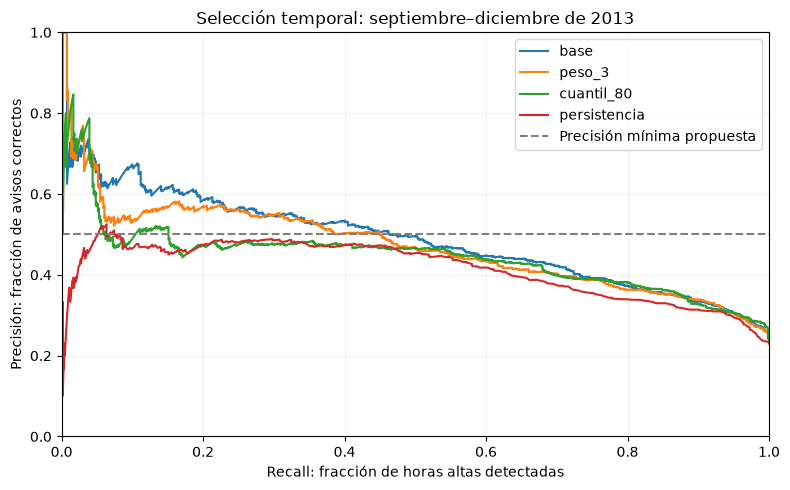

In [6]:
curvas, politicas = [], []
for nombre in [*CONFIGURACIONES, 'persistencia']:
    tabla = pd.DataFrame([{'umbral': int(t), **metricas(calibracion.real, calibracion[nombre], t)}
                          for t in REJILLA_UMBRALES])
    factibles = tabla.loc[tabla.precision >= PRECISION_MINIMA]
    if len(factibles):
        mejor = factibles.sort_values(['recall', 'precision', 'umbral'], ascending=False).iloc[0]
    else:
        mejor = tabla.sort_values(['F2', 'precision', 'umbral'], ascending=False).iloc[0]
    politicas.append({'modelo': nombre, 'umbral': int(mejor.umbral),
                      'cumple_calibracion': bool(len(factibles)),
                      **metricas(seleccion.real, seleccion[nombre], int(mejor.umbral))})
    curvas.append(tabla.assign(modelo=nombre))
curvas_calibracion = pd.concat(curvas, ignore_index=True)
politicas_seleccion = pd.DataFrame(politicas)
politicas_seleccion['cumple_seleccion'] = politicas_seleccion.precision >= PRECISION_MINIMA
factibles = politicas_seleccion.loc[politicas_seleccion.cumple_calibracion & politicas_seleccion.cumple_seleccion]
if len(factibles):
    elegida = factibles.sort_values(['recall', 'precision'], ascending=False).iloc[0]
    estado_seleccion = 'Cumple el mínimo en calibración y selección; pendiente de evaluación posterior'
else:
    elegida = politicas_seleccion.sort_values(['F2', 'precision'], ascending=False).iloc[0]
    estado_seleccion = 'Ninguna política cumple ambos periodos: referencia exploratoria por F2'
MODELO_ELEGIDO, UMBRAL_AVISO = str(elegida.modelo), int(elegida.umbral)
display(politicas_seleccion.round(3))
print(estado_seleccion)
print('Política congelada:', MODELO_ELEGIDO, '| aviso si score >', UMBRAL_AVISO)

fig, ax = plt.subplots(figsize=(8, 5))
for nombre in [*CONFIGURACIONES, 'persistencia']:
    d = seleccion.dropna(subset=['real', nombre])
    precision, recall, _ = precision_recall_curve(d.real > UMBRAL, d[nombre])
    ax.plot(recall, precision, label=nombre)
ax.axhline(PRECISION_MINIMA, color='grey', ls='--', label='Precisión mínima propuesta')
ax.set(xlabel='Recall: fracción de horas altas detectadas', ylabel='Precisión: fracción de avisos correctos',
       title='Selección temporal: septiembre–diciembre de 2013', xlim=(0, 1), ylim=(0, 1))
ax.legend(); ax.grid(alpha=.2); plt.tight_layout(); plt.show()

## 5. Evaluación reutilizada de 2014

Se reentrenan solo el modelo base y el elegido, si es diferente, con datos hasta
diciembre de 2013. El umbral queda congelado. Reajustar el modelo puede cambiar la
distribución de sus predicciones y la precisión del umbral: se informa sin corregirlo
mirando el test. Los resultados no se usan para volver a elegir.

Se comparan la política elegida, base > 150, persistencia > 150 y persistencia con
su propio umbral calibrado. No se confunde concentración media con score de cuantil.

In [7]:
indice_test = y.loc['2014-01-02':'2014-12-31 23:00'].index
test = pd.DataFrame({'real': real.loc[indice_test], 'persistencia': y.shift(H).loc[indice_test]})
modelos_finales = {}
for nombre in dict.fromkeys(['base', MODELO_ELEGIDO]):
    if nombre == 'persistencia':
        continue
    modelos_finales[nombre] = ajustar(nombre, '2013-12-31 23:00')
    test[nombre] = predecir(modelos_finales[nombre], indice_test)
umbral_naive = int(politicas_seleccion.loc[politicas_seleccion.modelo == 'persistencia', 'umbral'].iloc[0])
REGLAS = {
    'base_150': ('base', 150),
    'persistencia_150': ('persistencia', 150),
    'persistencia_ajustada': ('persistencia', umbral_naive),
    'elegida': (MODELO_ELEGIDO, UMBRAL_AVISO),
}
metricas_test = pd.DataFrame([
    {'politica': etiqueta, 'modelo': nombre, 'umbral': umbral,
     **metricas(test.real, test[nombre], umbral)}
    for etiqueta, (nombre, umbral) in REGLAS.items()
]).set_index('politica')
metricas_test['cumple_precision_minima'] = metricas_test.precision >= PRECISION_MINIMA
display(metricas_test.round(3))
print('¿Cumple la precisión propuesta en 2014?', bool(metricas_test.loc['elegida', 'cumple_precision_minima']))

,modelo,umbral,n,horas_altas,recall,precision,F2,AP,falsas_alarmas_h,omitidas_h,avisos_h,fraccion_h_con_aviso,RMSE,MAE,cumple_precision_minima
politica,,,,,,,,,,,,,,,
base_150,base,150,8637,1737,0.360,0.583,0.390,0.493,447,1111,1073,0.124,81.642,59.904,True
persistencia_150,persistencia,150,8637,1737,0.454,0.452,0.453,0.440,957,949,1745,0.202,99.624,67.789,False
persistencia_ajustada,persistencia,50,8637,1737,0.893,0.289,0.630,0.440,3814,186,5365,0.621,99.624,67.789,False
elegida,persistencia,50,8637,1737,0.893,0.289,0.630,0.440,3814,186,5365,0.621,99.624,67.789,False


¿Cumple la precisión propuesta en 2014? False


## 6. ¿Avisamos antes de que empiece un episodio?

Episodio: bloque consecutivo de horas **medidas** > 150, sin duración mínima.
Un hueco rompe el bloque y el siguiente bloque no tiene inicio confirmado hasta que
se observa una transición desde ≤ 150. Se excluyen bloques cuyo inicio no es observable
o cuya ventana de anticipación de 24 h queda fuera de la evaluación. Un episodio puede
seguir más allá del periodo evaluado: se informa el truncamiento de su final.

Un episodio se considera anticipado si existe una predicción de hora alta dentro de
ese episodio emitida **antes del inicio** (hora de emisión = hora objetivo − 24 h).
Se informa también detección en cualquier momento, para no confundirla con anticipación.
La anticipación es la máxima observada entre avisos válidos, no la duración del episodio.
Las falsas alarmas de la tabla previa son horas, no episodios independientes.

In [8]:
def episodios_observados(serie, indice_evaluacion):
    alta = serie.gt(UMBRAL)
    bloques = alta.ne(alta.shift(fill_value=False)).cumsum()
    registros = []
    for _, tramo in serie.loc[alta].groupby(bloques.loc[alta]):
        inicio, fin = tramo.index.min(), tramo.index.max()
        if inicio not in indice_evaluacion:
            continue
        previo = serie.get(inicio - pd.Timedelta(hours=1), np.nan)
        confirmado = bool(pd.notna(previo) and previo <= UMBRAL)
        cobertura = inicio + pd.Timedelta(hours=H-1) <= indice_evaluacion.max()
        registros.append({'inicio': inicio, 'fin': fin, 'duracion_h': len(tramo),
                          'inicio_observado': confirmado, 'cobertura_anticipacion': cobertura,
                          'fin_truncado': fin > indice_evaluacion.max()})
    return pd.DataFrame(registros, columns=['inicio','fin','duracion_h','inicio_observado',
                                          'cobertura_anticipacion','fin_truncado'])

def evaluar_episodios(episodios, score, umbral):
    detalles = []
    for e in episodios.itertuples():
        if not (e.inicio_observado and e.cobertura_anticipacion):
            continue
        avisos = score.loc[e.inicio:e.fin]
        horas_objetivo = avisos.index[avisos > umbral]
        emisiones = horas_objetivo - pd.Timedelta(hours=H)
        previas = emisiones[emisiones < e.inicio]
        detalles.append({'inicio': e.inicio, 'fin': e.fin, 'duracion_h': e.duracion_h,
                         'detectado': bool(len(horas_objetivo)), 'anticipado': bool(len(previas)),
                         'anticipacion_h': (e.inicio - previas.min()).total_seconds()/3600 if len(previas) else np.nan})
    return pd.DataFrame(detalles, columns=['inicio','fin','duracion_h','detectado','anticipado','anticipacion_h'])

episodios = episodios_observados(real, test.index)
detalle_episodios, resumen_episodios = [], []
for etiqueta, (nombre, umbral) in REGLAS.items():
    detalle = evaluar_episodios(episodios, test[nombre], umbral)
    detalle_episodios.append(detalle.assign(politica=etiqueta))
    resumen_episodios.append({'politica': etiqueta, 'episodios_evaluables': len(detalle),
        'episodios_anticipados': int(detalle.anticipado.sum()),
        'recall_episodios_anticipados': detalle.anticipado.mean(),
        'recall_episodios_detectados': detalle.detectado.mean(),
        'mediana_anticipacion_h_solo_aciertos': detalle.anticipacion_h.median()})
detalle_episodios = pd.concat(detalle_episodios, ignore_index=True)
resumen_episodios = pd.DataFrame(resumen_episodios).set_index('politica')
print('Bloques encontrados:', len(episodios), '| excluidos por inicio/cobertura:',
      int((~(episodios.inicio_observado & episodios.cobertura_anticipacion)).sum()))
display(resumen_episodios.round(3))

Bloques encontrados: 175 | excluidos por inicio/cobertura: 7


,episodios_evaluables,episodios_anticipados,recall_episodios_anticipados,recall_episodios_detectados,mediana_anticipacion_h_solo_aciertos
politica,,,,,
base_150,168,42,0.250,0.262,20.5
persistencia_150,168,55,0.327,0.351,24.0
persistencia_ajustada,168,145,0.863,0.863,24.0
elegida,168,145,0.863,0.863,24.0


## 7. Resultados y comprobaciones

Las gráficas muestran ventanas fijadas (enero y julio); no se eligen los mejores ejemplos.
El notebook mantiene skforecast y no ejecuta una búsqueda masiva. No añade nuevas variables
ni entrenamientos neuronales: permite comprobar primero si cambiar la política de aviso ayuda.

Equivalencia del lote verificada en tres orígenes de test
Comprobaciones de anticipación y huecos superadas


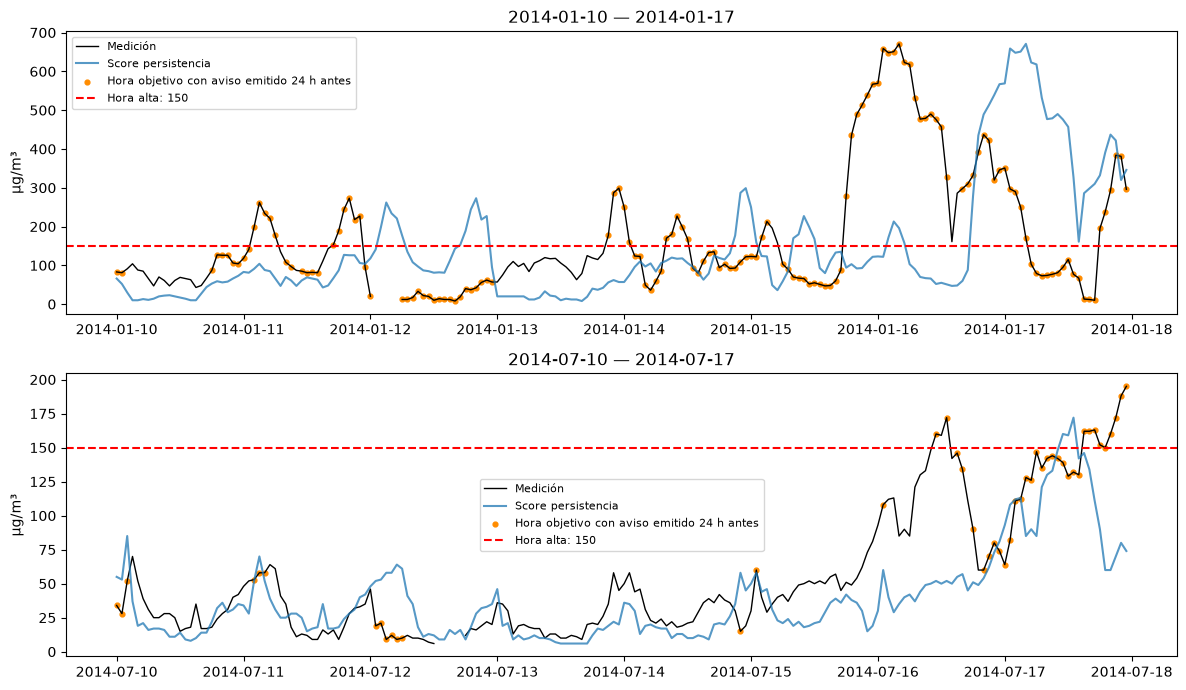

Política: persistencia | umbral: 50
Tiempo total: 17.9 s


In [9]:
# Comprobación de equivalencia entre lote y predict(24), sin cambiar los modelos.
f = modelos_finales['base']
for objetivo in indice_test[[0, len(indice_test)//2, -1]]:
    origen = objetivo - pd.Timedelta(hours=H)
    with threadpool_limits(limits=2):
        referencia = f.predict(steps=H, last_window=y.loc[:origen].tail(max(LAGS)),
            exog=exog.loc[origen + pd.Timedelta(hours=1):objetivo]).iloc[-1]
    np.testing.assert_allclose(test.loc[objetivo, 'base'], max(0, referencia), rtol=1e-9, atol=1e-8)
print('Equivalencia del lote verificada en tres orígenes de test')

# Ejemplo sintético: acierto tardío y aviso previo no son la misma cosa.
idx_s = pd.date_range('2020-01-01', periods=100, freq='h')
serie_s = pd.Series(0., index=idx_s); serie_s.iloc[30:61] = 200
ep_s = episodios_observados(serie_s, idx_s)
score_s = pd.Series(0., index=idx_s); score_s.iloc[59] = 200
assert not evaluar_episodios(ep_s, score_s, 150).iloc[0].anticipado
score_s.iloc[30] = 200
assert evaluar_episodios(ep_s, score_s, 150).iloc[0].anticipacion_h == 24
serie_s.iloc[29] = np.nan
assert not episodios_observados(serie_s, idx_s).iloc[0].inicio_observado
print('Comprobaciones de anticipación y huecos superadas')

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for ax, (inicio, fin) in zip(axes, [('2014-01-10', '2014-01-17'), ('2014-07-10', '2014-07-17')]):
    d = test.loc[inicio:fin]
    ax.plot(d.index, d.real, label='Medición', color='black', lw=1)
    ax.plot(d.index, d[MODELO_ELEGIDO], label=f'Score {MODELO_ELEGIDO}', alpha=.75)
    avisos = d.loc[(d[MODELO_ELEGIDO] > UMBRAL_AVISO) & d.real.notna()]
    ax.scatter(avisos.index, avisos.real, color='darkorange', s=12, label='Hora objetivo con aviso emitido 24 h antes')
    ax.axhline(UMBRAL, color='red', ls='--', label='Hora alta: 150')
    ax.set(title=f'{inicio} — {fin}', ylabel='µg/m³'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print('Política:', MODELO_ELEGIDO, '| umbral:', UMBRAL_AVISO)
print(f'Tiempo total: {perf_counter() - INICIO:.1f} s')


## Límites y siguientes pasos

- La precisión mínima del 50 % es exploratoria; establecer el coste tolerable de avisos falsos antes de decidir un uso operativo.
- El objetivo sigue siendo la superación **exactamente a 24 horas**, no cualquier superación dentro de las próximas 24 h. La evaluación por episodios es complementaria y no cambia la etiqueta del entrenamiento.
- Un episodio de una hora y uno largo pesan igual en recall por episodios. Informar duración y resultados estacionales antes de generalizar.
- No se atribuye una mejora al modelo comparando CSV distintos. Se debe usar la misma versión de los datos al comparar.
- La selección de arquitectura y los años ya fueron explorados; una evaluación independiente requiere otro periodo no utilizado.
- Siguientes experimentos: contexto causal de PM2.5, probabilidad calibrada de superación y métricas de falsas alertas agrupadas. Todas las nuevas variables deben estar disponibles al origen.

Fuentes: [ajuste de umbrales](https://scikit-learn.org/stable/modules/classification_threshold.html),
[pesos en skforecast](https://skforecast.org/latest/user_guides/weighted-time-series-forecasting.html),
[cuantiles en skforecast](https://skforecast.org/latest/user_guides/probabilistic-forecasting-quantile-regression.html),
[evaluación por intervalos](https://arxiv.org/abs/1803.03639).